<a href="https://colab.research.google.com/github/nisha037/Agriculture-yield-prediction/blob/main/Copy_of_Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. First 10 Records ---
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   

/tmp/ipykernel_3535/2614218740.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_3535/2614218740.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

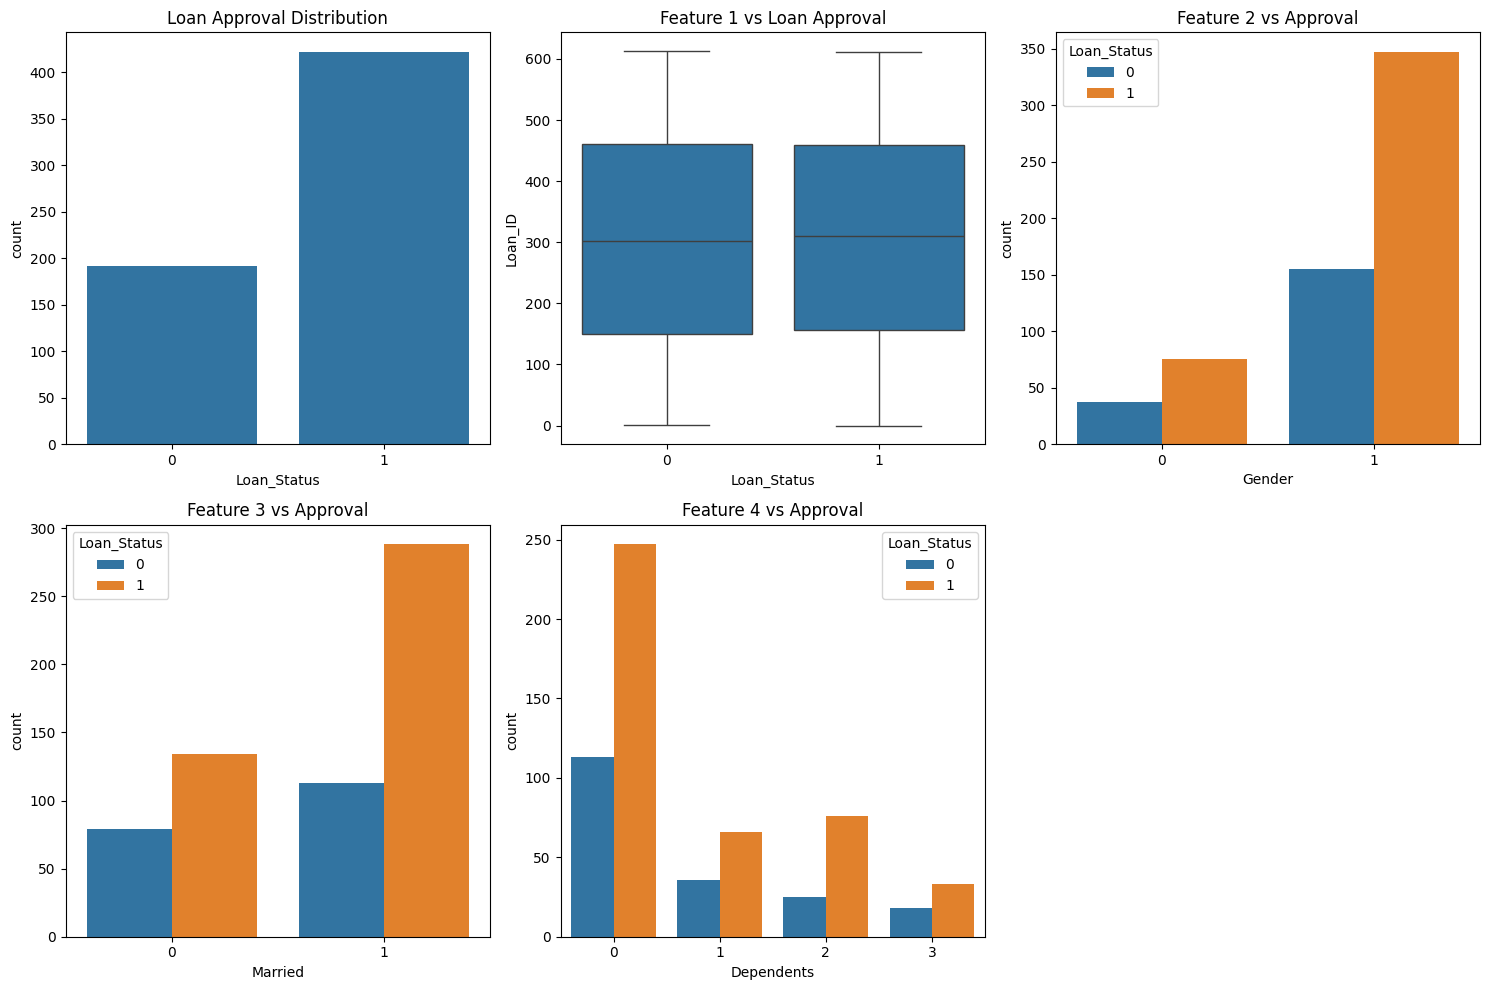


--- Model Comparison Table ---
                          Accuracy  Precision  Recall  F1 Score
Logistic Regression       0.788618   0.759615  0.9875  0.858696
Decision Tree Classifier  0.691057   0.750000  0.7875  0.768293
Random Forest Classifier  0.780488   0.757282  0.9750  0.852459

--- Stratified 5-Fold CV Results ---
Logistic Regression: Mean Accuracy = 0.8046, Std = 0.0254
Decision Tree Classifier: Mean Accuracy = 0.7053, Std = 0.0311
Random Forest Classifier: Mean Accuracy = 0.7850, Std = 0.0244

--- Hyperparameter Tuning (Random Forest) ---
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.8186147186147187
Tuned Model Test Accuracy: 0.7723577235772358

--- Decision Tree Depth Analysis Table ---
              Train Accuracy  Test Accuracy
max_depth=2         0.820774       0.788618
max_depth=5         0.855397       0.747967
max_depth=15        0.995927       0.699187


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================================================================
# QUESTION 1: Load Dataset & Initial Analysis
# ==============================================================================
# Tumhari uploaded file ka exact name yahan use kiya hai
df = pd.read_csv('Loan prediction.csv')

print("--- 1. First 10 Records ---")
print(df.head(10))

print("\n--- 2. Features and Target Variable ---")
print("Features:", list(df.columns[:-1]))
print("Target Variable:", df.columns[-1])

print("\n--- 3. Number of Records and Attributes ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- 4. Check for Missing Values ---")
print(df.isnull().sum())

print("\n--- 5. Statistical Properties ---")
print(df.describe())

# ==============================================================================
# QUESTION 2: Data Preprocessing
# ==============================================================================
# 1. Missing values handle karna
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# 2. Categorical columns ko number me badalna
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 3. Final feature matrix aur target variable banana
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 4. Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================================================================
# QUESTION 3: Exploratory Data Analysis (Visualizations)
# ==============================================================================
plt.figure(figsize=(15, 10))

# 1. Loan approval distribution
plt.subplot(2, 3, 1)
sns.countplot(x=y)
plt.title('Loan Approval Distribution')

# Baki plots ke liye base dynamic rakh rahe hain features ke hisab se
if X.shape[1] >= 4:
    plt.subplot(2, 3, 2)
    sns.boxplot(x=y, y=X.iloc[:, 0])
    plt.title('Feature 1 vs Loan Approval')

    plt.subplot(2, 3, 3)
    sns.countplot(x=X.iloc[:, 1], hue=y)
    plt.title('Feature 2 vs Approval')

    plt.subplot(2, 3, 4)
    sns.countplot(x=X.iloc[:, 2], hue=y)
    plt.title('Feature 3 vs Approval')

    plt.subplot(2, 3, 5)
    sns.countplot(x=X.iloc[:, 3], hue=y)
    plt.title('Feature 4 vs Approval')

plt.tight_layout()
plt.show()

# ==============================================================================
# QUESTION 4: Split & Train Models
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1 Score': f1_score(y_test, preds, zero_division=0)
    }

print("\n--- Model Comparison Table ---")
print(pd.DataFrame(results).T)

# ==============================================================================
# QUESTION 6: Stratified 5-Fold Cross Validation
# ==============================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- Stratified 5-Fold CV Results ---")
for name, model in models.items():
    fold_accuracies = []
    for train_idx, val_idx in skf.split(X_scaled, y):
        X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        fold_accuracies.append(accuracy_score(y_va, model.predict(X_va)))

    print(f"{name}: Mean Accuracy = {np.mean(fold_accuracies):.4f}, Std = {np.std(fold_accuracies):.4f}")

# ==============================================================================
# QUESTION 7: Hyperparameter Tuning using GridSearchCV
# ==============================================================================
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("\n--- Hyperparameter Tuning (Random Forest) ---")
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)
print("Tuned Model Test Accuracy:", accuracy_score(y_test, tuned_preds))

# ==============================================================================
# QUESTION 8: Bias-Variance Tradeoff (Decision Tree)
# ==============================================================================
depths = [2, 5, 15]
dt_results = {}

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    dt_results[f"max_depth={d}"] = {"Train Accuracy": train_acc, "Test Accuracy": test_acc}

print("\n--- Decision Tree Depth Analysis Table ---")
print(pd.DataFrame(dt_results).T)